<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/31_march_Regression_6_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Scientist master


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ML stack for Algerian Forest Fires demo (Q5)
from sklearn.linear_model  import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics       import mean_squared_error, r2_score
import pickle, os, json as _json

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F0F4F8',
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
})

C1,C2,C3,C4,C5,C6 = '#E94560','#0f3460','#457B9D','#2EC4B6','#FF9F1C','#533483'
print('✅  Libraries loaded successfully.')


✅  Libraries loaded successfully.


---
## Q1 — What are the key steps involved in building an end-to-end web application,
## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;from development to deployment on the cloud?


### 📖 Theory

Building an end-to-end web application involves **8 major phases**, from initial planning
to live cloud deployment and ongoing maintenance.

---

#### Phase 1 — Requirements & Planning
- Define application scope, target users, and key features
- Choose tech stack (frontend, backend, database, ML framework)
- Set up version control (Git/GitHub), project board, and CI/CD strategy

#### Phase 2 — Data Pipeline & Model Development *(ML apps)*
- Data collection, EDA, feature engineering
- Model training, validation, and hyperparameter tuning
- Serialise model (`pickle` / `joblib`)

#### Phase 3 — Backend Development
- Build REST API endpoints using **Flask** or **FastAPI**
- Load trained model and expose `/predict` endpoint
- Input validation, error handling, logging

#### Phase 4 — Frontend Development
- Design responsive UI (HTML/CSS/Bootstrap or React)
- Connect UI to backend API via `fetch()` / `axios`
- Display predictions, charts, and feedback to user

#### Phase 5 — Local Testing
- Unit tests, integration tests, API tests (Postman / pytest)
- Test edge cases, error states, and model performance

#### Phase 6 — Containerisation
- Write `Dockerfile` → build Docker image
- Test container locally: `docker build`, `docker run`
- Push image to Docker Hub or cloud container registry

#### Phase 7 — Cloud Deployment
- Choose platform: **AWS Elastic Beanstalk**, **Heroku**, **GCP App Engine**, **Azure App Service**
- Configure environment variables, secrets, scaling rules
- Deploy via CLI, GitHub Actions, or cloud console

#### Phase 8 — Monitoring & Maintenance
- Set up logging (CloudWatch, Stackdriver)
- Monitor model drift, API latency, error rates
- Automate retraining pipeline as needed

---

#### Tech Stack for ML Web App (Example)

| Layer | Technology |
|-------|------------|
| **ML Model** | scikit-learn, TensorFlow, PyTorch |
| **Backend API** | Flask / FastAPI |
| **Frontend** | HTML + CSS + Bootstrap / React |
| **Containerisation** | Docker |
| **Cloud Platform** | AWS / GCP / Azure / Heroku |
| **CI/CD** | GitHub Actions / Jenkins |
| **Monitoring** | CloudWatch / Prometheus + Grafana |


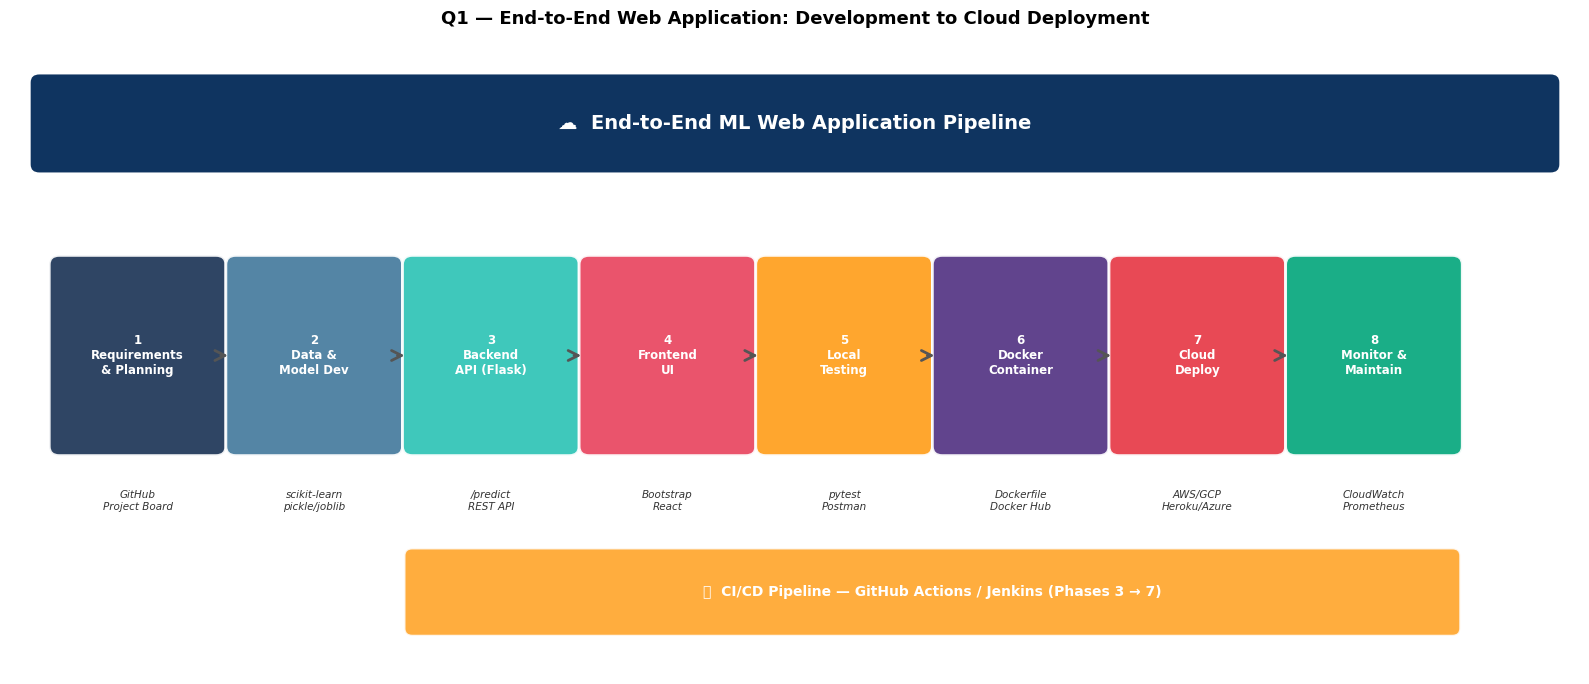

8 phases from planning → live cloud deployment + monitoring.


In [2]:
# ── Q1: End-to-End Pipeline Diagram ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(0, 16); ax.set_ylim(0, 7)
ax.axis('off')

phases = [
    ('1\nRequirements\n& Planning',    '#1D3557', 0.5),
    ('2\nData &\nModel Dev',           '#457B9D', 2.3),
    ('3\nBackend\nAPI (Flask)',        '#2EC4B6', 4.1),
    ('4\nFrontend\nUI',               '#E94560', 5.9),
    ('5\nLocal\nTesting',             '#FF9F1C', 7.7),
    ('6\nDocker\nContainer',          '#533483', 9.5),
    ('7\nCloud\nDeploy',              '#E63946', 11.3),
    ('8\nMonitor &\nMaintain',        '#06A77D', 13.1),
]

for label, color, x in phases:
    # Box
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, 2.5), 1.6, 2.0,
        boxstyle='round,pad=0.1',
        facecolor=color, edgecolor='white', lw=2, alpha=0.92
    ))
    ax.text(x+0.80, 3.50, label, ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold')
    # Arrow to next
    if x < 13.1:
        ax.annotate('', xy=(x+1.75, 3.50), xytext=(x+1.62, 3.50),
                    arrowprops=dict(arrowstyle='->', color='#555555',
                                   lw=2.0, mutation_scale=18))

# Title bar
ax.add_patch(mpatches.FancyBboxPatch(
    (0.3, 5.6), 15.4, 0.9,
    boxstyle='round,pad=0.1',
    facecolor='#0f3460', edgecolor='white', lw=1.5
))
ax.text(8.0, 6.05, '☁️  End-to-End ML Web Application Pipeline',
        ha='center', va='center', fontsize=14, color='white', fontweight='bold')

# Sub-labels
sub = [
    ('GitHub\nProject Board', 0.5),
    ('scikit-learn\npickle/joblib', 2.3),
    ('/predict\nREST API', 4.1),
    ('Bootstrap\nReact', 5.9),
    ('pytest\nPostman', 7.7),
    ('Dockerfile\nDocker Hub', 9.5),
    ('AWS/GCP\nHeroku/Azure', 11.3),
    ('CloudWatch\nPrometheus', 13.1),
]
for text, x in sub:
    ax.text(x+0.80, 1.9, text, ha='center', va='center',
            fontsize=7.5, color='#333333', style='italic')

# CI/CD bar
ax.add_patch(mpatches.FancyBboxPatch(
    (4.1, 0.5), 10.6, 0.8,
    boxstyle='round,pad=0.08',
    facecolor='#FF9F1C', edgecolor='white', lw=1.5, alpha=0.85
))
ax.text(9.4, 0.90, '🔄  CI/CD Pipeline — GitHub Actions / Jenkins (Phases 3 → 7)',
        ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.suptitle('Q1 — End-to-End Web Application: Development to Cloud Deployment',
             fontsize=13, fontweight='bold', y=0.97)
plt.tight_layout()
plt.show()
print('8 phases from planning → live cloud deployment + monitoring.')


---
## Q2 — Explain the difference between traditional web hosting and cloud hosting.


### 📖 Theory

#### Traditional Web Hosting
In traditional hosting, your application runs on a **fixed, dedicated or shared physical server**.
Resources (CPU, RAM, storage) are pre-allocated and cannot scale automatically.

- **Shared Hosting** — Multiple sites share one server (cheapest, least control)
- **VPS (Virtual Private Server)** — Dedicated slice of a physical machine
- **Dedicated Server** — Entire physical machine reserved for one application

#### Cloud Hosting
Cloud hosting runs on a **virtualised network of interconnected servers** managed by a
cloud provider (AWS, GCP, Azure). Resources scale automatically on demand.

---

#### Comparison Table

| Dimension | Traditional Hosting | Cloud Hosting |
|-----------|--------------------|--------------|
| **Infrastructure** | Fixed physical servers | Virtualised, distributed |
| **Scalability** | Manual, limited | Auto-scaling, instant |
| **Cost model** | Fixed monthly/yearly fee | Pay-as-you-go |
| **Availability / SLA** | 99–99.9% typical | 99.95–99.999% (multi-AZ) |
| **Setup time** | Hours to days | Minutes |
| **Disaster recovery** | Manual backups | Built-in replication |
| **Global reach** | Single location | Multiple regions worldwide |
| **Maintenance** | User / hosting company | Provider managed |
| **Best for** | Small, static sites | ML apps, variable traffic |
| **Examples** | GoDaddy, Bluehost, cPanel | AWS, GCP, Azure, Heroku |

---

#### Cloud Service Models

| Model | What you manage | Examples |
|-------|----------------|----------|
| **IaaS** (Infra as a Service) | OS, runtime, app | AWS EC2, Azure VM |
| **PaaS** (Platform as a Service) | App code only | Heroku, GCP App Engine |
| **SaaS** (Software as a Service) | Nothing | Gmail, Salesforce |


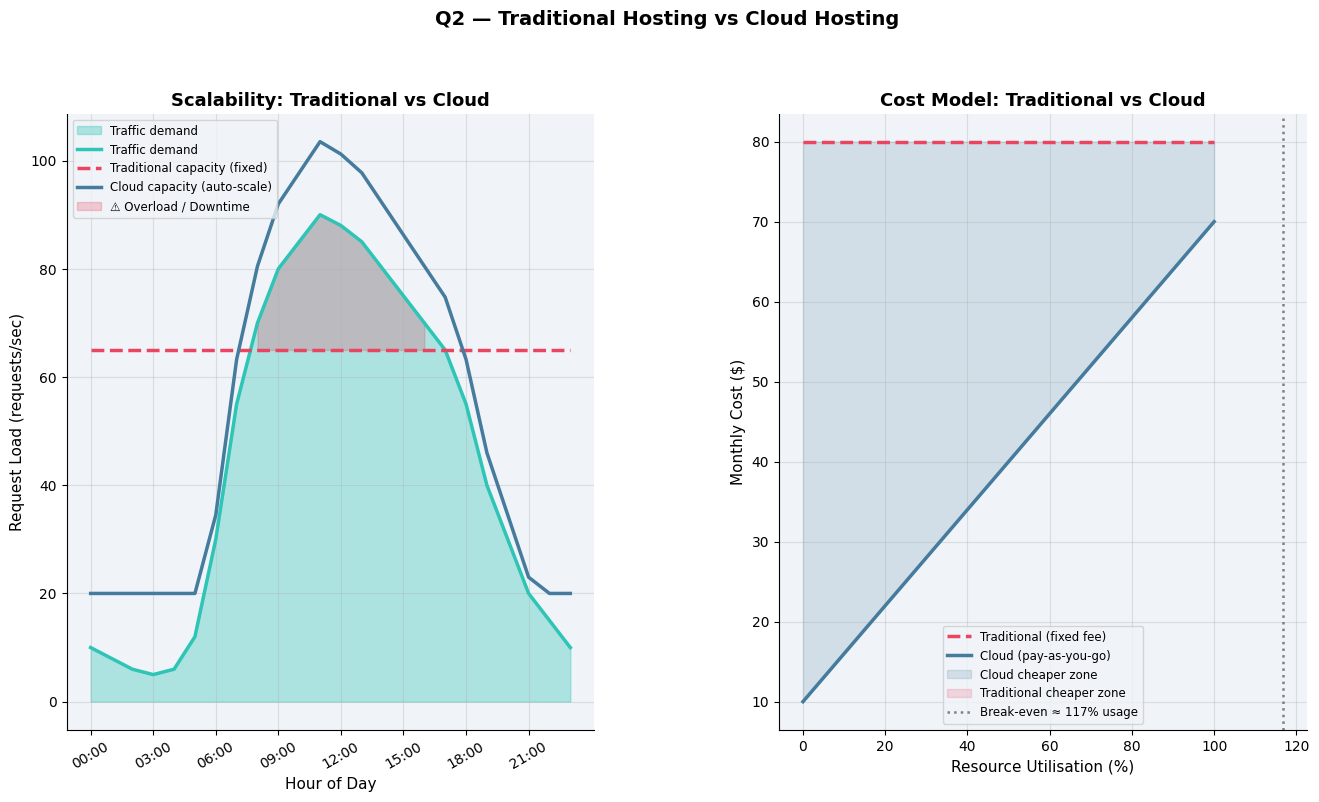


Cloud Service Models — Responsibility Stack
  Layer                On-Premises        IaaS            PaaS          SaaS   
  ------------------------------------------------------------
  Data                    👤 You           👤 You           👤 You        ☁ Provider   
  App Code                👤 You           👤 You           👤 You        ☁ Provider   
  Middleware              👤 You           👤 You        ☁ Provider      ☁ Provider   
  Runtime                 👤 You           👤 You        ☁ Provider      ☁ Provider   
  OS                      👤 You           👤 You        ☁ Provider      ☁ Provider   
  Virtualisation          👤 You        ☁ Provider      ☁ Provider      ☁ Provider   
  Servers                 👤 You        ☁ Provider      ☁ Provider      ☁ Provider   
  Storage                 👤 You        ☁ Provider      ☁ Provider      ☁ Provider   
  Networking              👤 You        ☁ Provider      ☁ Provider      ☁ Provider   


In [3]:
# ── Q2: Traditional vs Cloud Hosting — Visual Comparison ────────────────────
fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Panel 1: Scalability comparison (traffic spike) ──────────────────────────
time_pts = np.arange(24)
traffic  = np.array([10,8,6,5,6,12,30,55,70,80,85,90,
                      88,85,80,75,70,65,55,40,30,20,15,10])

trad_capacity = np.full(24, 65)   # fixed
cloud_cap     = np.clip(traffic * 1.15, 20, 120)  # auto-scale

ax1.fill_between(time_pts, traffic, alpha=0.35, color=C4, label='Traffic demand')
ax1.plot(time_pts, traffic,       color=C4,  lw=2.5, label='Traffic demand')
ax1.plot(time_pts, trad_capacity, color=C1,  lw=2.5, ls='--', label='Traditional capacity (fixed)')
ax1.plot(time_pts, cloud_cap,     color=C3,  lw=2.5, ls='-',  label='Cloud capacity (auto-scale)')

# Shade overload zone
ax1.fill_between(time_pts, trad_capacity, traffic,
                  where=(traffic > trad_capacity),
                  alpha=0.25, color=C1, label='⚠ Overload / Downtime')

ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Request Load (requests/sec)', fontsize=11)
ax1.set_title('Scalability: Traditional vs Cloud', fontsize=13, fontweight='bold')
ax1.legend(fontsize=8.5, loc='upper left')
ax1.set_xticks(range(0,24,3))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0,24,3)], rotation=30)

# ── Panel 2: Cost model comparison ───────────────────────────────────────────
usage = np.linspace(0, 100, 200)
trad_cost  = np.full_like(usage, 80)          # fixed monthly cost
cloud_cost = 10 + usage * 0.60                # pay-as-you-go

ax2.plot(usage, trad_cost,  color=C1, lw=2.5, ls='--', label='Traditional (fixed fee)')
ax2.plot(usage, cloud_cost, color=C3, lw=2.5,           label='Cloud (pay-as-you-go)')
ax2.fill_between(usage, trad_cost, cloud_cost,
                  where=(cloud_cost < trad_cost), alpha=0.18,
                  color=C3, label='Cloud cheaper zone')
ax2.fill_between(usage, trad_cost, cloud_cost,
                  where=(cloud_cost >= trad_cost), alpha=0.18,
                  color=C1, label='Traditional cheaper zone')

crossover = (80 - 10) / 0.60
ax2.axvline(crossover, color='grey', ls=':', lw=1.8,
             label=f'Break-even ≈ {crossover:.0f}% usage')
ax2.set_xlabel('Resource Utilisation (%)', fontsize=11)
ax2.set_ylabel('Monthly Cost ($)', fontsize=11)
ax2.set_title('Cost Model: Traditional vs Cloud', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8.5)

plt.suptitle('Q2 — Traditional Hosting vs Cloud Hosting',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# IaaS / PaaS / SaaS table
print('\nCloud Service Models — Responsibility Stack')
print('='*65)
layers = ['Networking','Storage','Servers','Virtualisation',
           'OS','Runtime','Middleware','App Code','Data']
print(f"  {'Layer':18} {'On-Premises':^15} {'IaaS':^15} {'PaaS':^15} {'SaaS':^10}")
print('  ' + '-'*60)
you_manage = {
    'On-Premises': layers,
    'IaaS'       : ['OS','Runtime','Middleware','App Code','Data'],
    'PaaS'       : ['App Code','Data'],
    'SaaS'       : [],
}
for layer in reversed(layers):
    row = f"  {layer:18}"
    for model in ['On-Premises','IaaS','PaaS','SaaS']:
        sym = '👤 You' if layer in you_manage[model] else '☁ Provider'
        row += f" {sym:^15}"
    print(row)


---
## Q3 — How do you choose the right cloud provider, and what factors should you consider?


### 📖 Theory

Selecting the right cloud provider is a **strategic decision** that affects cost, performance,
compliance, and developer productivity. The three major providers are:

| Provider | Market Share | ML/AI Services | Best Known For |
|----------|-------------|----------------|----------------|
| **AWS** (Amazon) | ~32% | SageMaker, Rekognition | Widest service catalog |
| **Azure** (Microsoft) | ~22% | Azure ML, Cognitive Services | Enterprise, Windows, .NET |
| **GCP** (Google) | ~11% | Vertex AI, BigQuery ML | Data analytics, Kubernetes |
| **Heroku** | Niche | — | Simple PaaS, fast deploy |
| **Render/Railway** | Niche | — | Developer-friendly, free tiers |

---

#### Key Decision Factors

| Factor | What to Evaluate |
|--------|------------------|
| **Cost & Pricing** | On-demand vs reserved instances; free tier availability; egress costs |
| **Scalability** | Auto-scaling groups, serverless options, managed Kubernetes |
| **ML/AI Services** | Pre-built models, managed training, model registry, endpoints |
| **Geographic Regions** | Proximity to users; data residency / GDPR compliance |
| **Security & Compliance** | IAM, VPC, SOC2, HIPAA, ISO 27001 certifications |
| **Ecosystem / Integrations** | Existing tools, databases, DevOps toolchain |
| **Support & SLA** | Response time SLAs, uptime guarantees, documentation quality |
| **Vendor Lock-in Risk** | Portability of services; open-source alternatives |
| **Team Expertise** | Existing skills and certifications on the team |

---

#### Recommended for ML Web Apps (Data Science Context)

```
Simple prototype    → Heroku / Render (free tier, git-push deploy)
Medium production   → AWS Elastic Beanstalk or GCP App Engine
Enterprise ML       → AWS SageMaker or Azure ML
Data-heavy apps     → GCP (BigQuery + Vertex AI)
Microsoft ecosystem → Azure
```


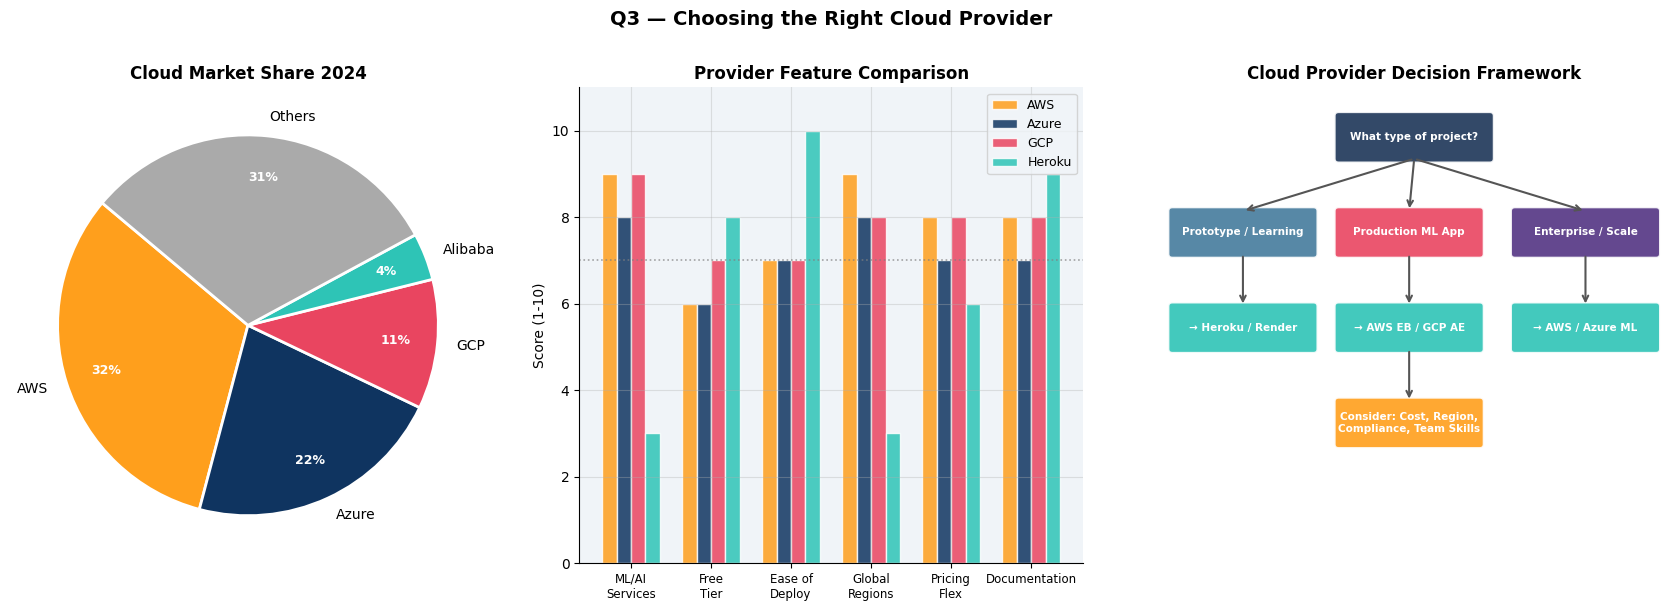

In [4]:
# ── Q3: Cloud Provider Comparison Dashboard ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# ── Panel 1: Market share ─────────────────────────────────────────────────────
providers  = ['AWS', 'Azure', 'GCP', 'Alibaba', 'Others']
mkt_shares = [32, 22, 11, 4, 31]
colors_mkt = [C5, C2, C1, C4, '#AAAAAA']
wedges, texts, autotexts = axes[0].pie(
    mkt_shares, labels=providers, autopct='%1.0f%%',
    colors=colors_mkt, startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2},
    pctdistance=0.78
)
for at in autotexts:
    at.set_fontsize(9); at.set_color('white'); at.set_fontweight('bold')
axes[0].set_title('Cloud Market Share 2024', fontsize=12, fontweight='bold')

# ── Panel 2: Feature radar / bar comparison ───────────────────────────────────
criteria = ['ML/AI\nServices','Free\nTier','Ease of\nDeploy','Global\nRegions',
             'Pricing\nFlex','Documentation']
scores = {
    'AWS'   : [9, 6, 7, 9, 8, 8],
    'Azure' : [8, 6, 7, 8, 7, 7],
    'GCP'   : [9, 7, 7, 8, 8, 8],
    'Heroku': [3, 8, 10,3, 6, 9],
}
x3  = np.arange(len(criteria))
w3  = 0.18
off = [-1.5,-0.5,0.5,1.5]
cols3 = [C5, C2, C1, C4]
for (name, sc), col, o in zip(scores.items(), cols3, off):
    axes[1].bar(x3+o*w3, sc, w3, color=col, alpha=0.85,
                 edgecolor='white', label=name)
axes[1].set_xticks(x3); axes[1].set_xticklabels(criteria, fontsize=8.5)
axes[1].set_ylim(0, 11); axes[1].set_ylabel('Score (1-10)')
axes[1].set_title('Provider Feature Comparison', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axhline(7, color='grey', ls=':', lw=1.2, alpha=0.7)

# ── Panel 3: Decision framework flowchart ────────────────────────────────────
axes[2].axis('off')
axes[2].set_xlim(0,10); axes[2].set_ylim(0,10)

boxes = [
    # (x, y, w, h, text, color)
    (3.5, 8.5, 3.0, 0.9, 'What type of project?', '#1D3557'),
    (0.2, 6.5, 2.8, 0.9, 'Prototype / Learning', '#457B9D'),
    (3.5, 6.5, 2.8, 0.9, 'Production ML App',    '#E94560'),
    (7.0, 6.5, 2.8, 0.9, 'Enterprise / Scale',   '#533483'),
    (0.2, 4.5, 2.8, 0.9, '→ Heroku / Render',    '#2EC4B6'),
    (3.5, 4.5, 2.8, 0.9, '→ AWS EB / GCP AE',   '#2EC4B6'),
    (7.0, 4.5, 2.8, 0.9, '→ AWS / Azure ML',    '#2EC4B6'),
    (3.5, 2.5, 2.8, 0.9, 'Consider: Cost, Region,\nCompliance, Team Skills','#FF9F1C'),
]
for (bx,by,bw,bh,txt,bc) in boxes:
    axes[2].add_patch(mpatches.FancyBboxPatch(
        (bx, by), bw, bh, boxstyle='round,pad=0.08',
        facecolor=bc, edgecolor='white', lw=1.5, alpha=0.90
    ))
    axes[2].text(bx+bw/2, by+bh/2, txt, ha='center', va='center',
                 fontsize=7.5, color='white', fontweight='bold')

# Arrows
for (x1,y1,x2,y2) in [
    (5.0,8.5, 1.6,7.4), (5.0,8.5, 4.9,7.4), (5.0,8.5, 8.4,7.4),
    (1.6,6.5, 1.6,5.4), (4.9,6.5, 4.9,5.4), (8.4,6.5, 8.4,5.4),
    (4.9,4.5, 4.9,3.4),
]:
    axes[2].annotate('', xy=(x2,y2), xytext=(x1,y1),
                      arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

axes[2].set_title('Cloud Provider Decision Framework', fontsize=12, fontweight='bold')

plt.suptitle('Q3 — Choosing the Right Cloud Provider',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q4 — How do you design and build a responsive user interface, and what are best practices?


### 📖 Theory

A **responsive UI** adapts its layout and components to different screen sizes (mobile, tablet, desktop)
using flexible grids, fluid images, and CSS media queries.

#### Core Responsive Design Principles

| Principle | Description |
|-----------|-------------|
| **Mobile-first** | Design for smallest screen first, then scale up |
| **Fluid grids** | Use `%` or CSS Grid / Flexbox instead of fixed `px` widths |
| **Flexible images** | `max-width: 100%` — images never exceed container |
| **Media queries** | CSS breakpoints: `@media (max-width: 768px) { ... }` |
| **CSS Frameworks** | Bootstrap, Tailwind CSS — pre-built responsive components |

---

#### Best Practices for ML Web App UI

| Category | Best Practice |
|----------|---------------|
| **Layout** | Use Bootstrap Grid (12-column) or CSS Flexbox |
| **Forms** | Clear labels, input validation, helpful error messages |
| **Feedback** | Loading spinner while model predicts; clear result display |
| **Accessibility** | `aria-label`, tab navigation, colour contrast ratio ≥ 4.5:1 |
| **Performance** | Minify CSS/JS, lazy-load images, use CDN |
| **Consistency** | Consistent typography, spacing (8px grid), colour palette |
| **Error handling** | Show user-friendly messages, not raw stack traces |

---

#### Sample Flask + Bootstrap App Structure

```
project/
├── app.py                  ← Flask backend
├── model/
│   └── forest_fire.pkl     ← Trained ML model
├── templates/
│   ├── index.html          ← Main UI (Bootstrap)
│   └── result.html         ← Prediction result page
├── static/
│   ├── css/style.css       ← Custom styles
│   └── js/app.js           ← AJAX / form handling
├── requirements.txt
└── Dockerfile
```

#### HTML Form → Flask → ML Model Flow
```
User fills form → POST /predict → Flask loads model
             → model.predict(input) → return JSON
             → JS updates DOM with result
```


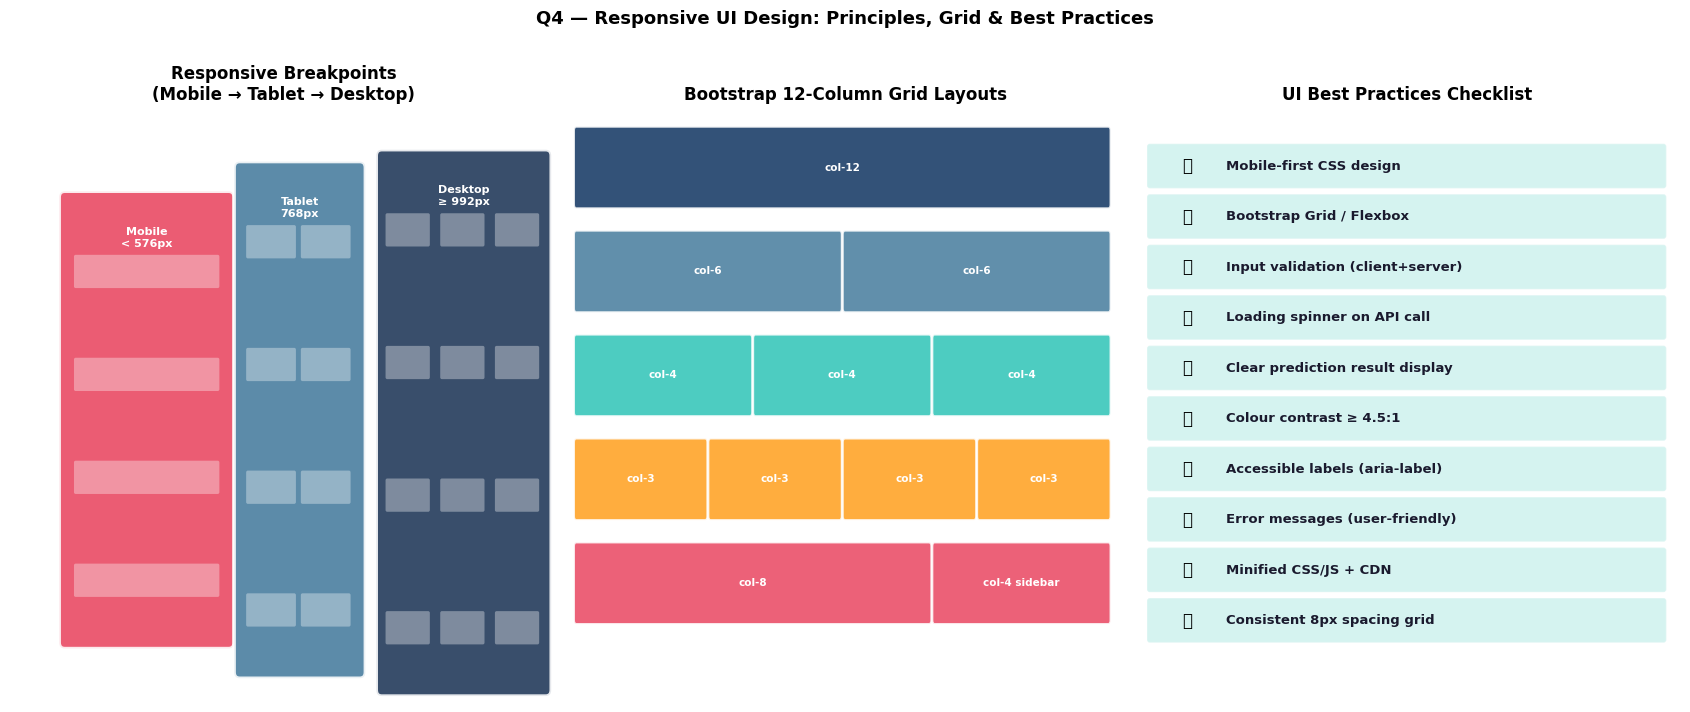


# ── app.py — Flask Backend Skeleton ─────────────────────────────────────────
from flask import Flask, request, jsonify, render_template
import pickle, numpy as np

app = Flask(__name__)

# Load model once at startup
with open('model/forest_fire.pkl', 'rb') as f:
    bundle = pickle.load(f)
model, scaler = bundle['model'], bundle['scaler']

@app.route('/')
def index():
    return render_template('index.html')   # serves Bootstrap form

@app.route('/predict', methods=['POST'])
def predict():
    data   = request.get_json()            # receive form data as JSON
    X      = np.array(data['features']).reshape(1,-1)
    X_sc   = scaler.transform(X)
    pred   = model.predict(X_sc)[0]
    return jsonify({'fwi_prediction': round(float(pred), 2)})

if __name__ == '__main__':
    app.run(debug=True, port=5000)



In [5]:
# ── Q4: Responsive UI concepts visualised + sample HTML/CSS/Flask code ───────
fig, axes = plt.subplots(1, 3, figsize=(17, 7))

# ── Panel 1: Responsive breakpoints ──────────────────────────────────────────
axes[0].axis('off')
axes[0].set_xlim(0,10); axes[0].set_ylim(0,10)

devices = [
    (1.0, 1.0, 3.0, 7.5, 'Mobile\n< 576px',  '#E94560', 'single\ncolumn'),
    (4.2, 0.5, 2.2, 8.5, 'Tablet\n768px',    '#457B9D', '2-col\ngrid'),
    (6.8, 0.2, 3.0, 9.0, 'Desktop\n≥ 992px', '#1D3557', '3-col\ngrid'),
]
for (dx,dy,dw,dh,label,col,layout) in devices:
    axes[0].add_patch(mpatches.FancyBboxPatch(
        (dx,dy), dw, dh, boxstyle='round,pad=0.1',
        facecolor=col, edgecolor='white', lw=2.5, alpha=0.88
    ))
    axes[0].text(dx+dw/2, dy+dh-0.5, label, ha='center', va='top',
                 fontsize=8, color='white', fontweight='bold')
    # Mock content blocks
    for row_y in np.linspace(dy+0.8, dy+dh-1.5, 4):
        if '2-col' in layout:
            for cx in [dx+0.15, dx+dw/2+0.05]:
                axes[0].add_patch(mpatches.FancyBboxPatch(
                    (cx, row_y), dw/2-0.25, 0.5,
                    boxstyle='round,pad=0.03',
                    facecolor='white', alpha=0.35, edgecolor='none'))
        elif '3-col' in layout:
            for cx in [dx+0.1, dx+dw/3+0.1, dx+2*dw/3+0.1]:
                axes[0].add_patch(mpatches.FancyBboxPatch(
                    (cx, row_y), dw/3-0.25, 0.5,
                    boxstyle='round,pad=0.03',
                    facecolor='white', alpha=0.35, edgecolor='none'))
        else:
            axes[0].add_patch(mpatches.FancyBboxPatch(
                (dx+0.2, row_y), dw-0.4, 0.5,
                boxstyle='round,pad=0.03',
                facecolor='white', alpha=0.35, edgecolor='none'))

axes[0].set_title('Responsive Breakpoints\n(Mobile → Tablet → Desktop)',
                   fontsize=12, fontweight='bold')

# ── Panel 2: Bootstrap Grid system ───────────────────────────────────────────
axes[1].axis('off')
axes[1].set_xlim(0,12); axes[1].set_ylim(0,8)
axes[1].set_title('Bootstrap 12-Column Grid Layouts',
                   fontsize=12, fontweight='bold')

layouts = [
    ([12],             ['col-12'],                         7.2, C2),
    ([6,6],            ['col-6','col-6'],                  5.8, C3),
    ([4,4,4],          ['col-4','col-4','col-4'],          4.4, C4),
    ([3,3,3,3],        ['col-3','col-3','col-3','col-3'],  3.0, C5),
    ([8,4],            ['col-8','col-4 sidebar'],          1.6, C1),
]
for (widths, labels, y_pos, col) in layouts:
    x_cur = 0.1
    total = 12
    for w, lbl in zip(widths, labels):
        box_w = (w / total) * 11.8
        axes[1].add_patch(mpatches.FancyBboxPatch(
            (x_cur, y_pos-0.5), box_w-0.12, 1.0,
            boxstyle='round,pad=0.05',
            facecolor=col, edgecolor='white', lw=1.5, alpha=0.85
        ))
        axes[1].text(x_cur+box_w/2-0.06, y_pos, lbl,
                     ha='center', va='center',
                     fontsize=7.5, color='white', fontweight='bold')
        x_cur += box_w + 0.0

# ── Panel 3: Best practices checklist ────────────────────────────────────────
axes[2].axis('off')
axes[2].set_xlim(0,10); axes[2].set_ylim(0,10)
axes[2].set_title('UI Best Practices Checklist', fontsize=12, fontweight='bold')

checklist = [
    ('✅', 'Mobile-first CSS design',        C4),
    ('✅', 'Bootstrap Grid / Flexbox',       C4),
    ('✅', 'Input validation (client+server)',C4),
    ('✅', 'Loading spinner on API call',    C4),
    ('✅', 'Clear prediction result display',C4),
    ('✅', 'Colour contrast ≥ 4.5:1',       C4),
    ('✅', 'Accessible labels (aria-label)', C4),
    ('✅', 'Error messages (user-friendly)',  C4),
    ('✅', 'Minified CSS/JS + CDN',          C4),
    ('✅', 'Consistent 8px spacing grid',    C4),
]
for i, (icon, text, col) in enumerate(checklist):
    y_c = 9.0 - i*0.85
    axes[2].add_patch(mpatches.FancyBboxPatch(
        (0.3, y_c-0.30), 9.4, 0.65,
        boxstyle='round,pad=0.05',
        facecolor=col, edgecolor='white', lw=1.2, alpha=0.20
    ))
    axes[2].text(0.9, y_c+0.02, icon, fontsize=12, va='center')
    axes[2].text(1.7, y_c+0.02, text, fontsize=9.5, va='center',
                 color='#1a1a2e', fontweight='bold')

plt.suptitle('Q4 — Responsive UI Design: Principles, Grid & Best Practices',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print sample Flask app skeleton
flask_code = '''
# ── app.py — Flask Backend Skeleton ─────────────────────────────────────────
from flask import Flask, request, jsonify, render_template
import pickle, numpy as np

app = Flask(__name__)

# Load model once at startup
with open('model/forest_fire.pkl', 'rb') as f:
    bundle = pickle.load(f)
model, scaler = bundle['model'], bundle['scaler']

@app.route('/')
def index():
    return render_template('index.html')   # serves Bootstrap form

@app.route('/predict', methods=['POST'])
def predict():
    data   = request.get_json()            # receive form data as JSON
    X      = np.array(data['features']).reshape(1,-1)
    X_sc   = scaler.transform(X)
    pred   = model.predict(X_sc)[0]
    return jsonify({'fwi_prediction': round(float(pred), 2)})

if __name__ == '__main__':
    app.run(debug=True, port=5000)
'''
print(flask_code)


---
## Q5 — How do you integrate the ML model with the UI for the Algerian Forest Fires project?
## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;What APIs or libraries can be used?


### 📖 Theory

The **Algerian Forest Fires Dataset** contains meteorological data from two regions of Algeria
(Bejaia and Sidi Bel-Abbes) and is used to predict the **Fire Weather Index (FWI)**.

#### Dataset Features

| Feature | Description | Unit |
|---------|-------------|------|
| `Temperature` | Max temperature at noon | °C |
| `RH` | Relative Humidity | % |
| `Ws` | Wind Speed | km/h |
| `Rain` | Daily rainfall | mm |
| `FFMC` | Fine Fuel Moisture Code | — |
| `DMC` | Duff Moisture Code | — |
| `DC` | Drought Code | — |
| `ISI` | Initial Spread Index | — |
| `BUI` | Buildup Index | — |
| `FWI` | **Fire Weather Index (target)** | — |

---

#### Integration Architecture

```
 ┌─────────────────────────────────────────────────────────────────┐
 │                    BROWSER (Bootstrap UI)                        │
 │  [Input Form: Temp, RH, Ws, Rain, FFMC, DMC, DC, ISI, BUI]      │
 │  → fetch('/predict', {method:'POST', body: JSON})                │
 │  ← Display FWI prediction + risk category                        │
 └──────────────────┬──────────────────────────────────────────────┘
                    │  HTTP POST /predict  (JSON payload)
 ┌──────────────────▼──────────────────────────────────────────────┐
 │               Flask API  (app.py)                                │
 │  1. Parse JSON → numpy array                                     │
 │  2. scaler.transform(X)                                          │
 │  3. model.predict(X_scaled)                                      │
 │  4. return jsonify({'fwi': prediction})                          │
 └──────────────────┬──────────────────────────────────────────────┘
                    │
 ┌──────────────────▼──────────────────────────────────────────────┐
 │         ML Model (Ridge Regression) + StandardScaler             │
 │         Saved as forest_fire_model.pkl (pickle / joblib)         │
 └─────────────────────────────────────────────────────────────────┘
```

#### Libraries & APIs Used

| Component | Library / Tool |
|-----------|----------------|
| **ML Model** | `scikit-learn` (Ridge, StandardScaler) |
| **Serialisation** | `pickle` / `joblib` |
| **Web Framework** | `Flask` |
| **HTTP API** | Flask RESTful route (`/predict`) |
| **Frontend** | HTML5 + Bootstrap 5 + vanilla JS `fetch()` |
| **Data Handling** | `numpy`, `pandas` |
| **Deployment** | AWS Elastic Beanstalk / Heroku (`Procfile`) |
| **Container** | `Docker` (`Dockerfile`) |


In [6]:
# ── Q5: Algerian Forest Fires — Full ML Pipeline + Flask Integration Demo ────
import numpy as np, pandas as pd, pickle
from sklearn.linear_model    import Ridge
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_squared_error, r2_score

np.random.seed(42)

# ── Step 1: Simulate Algerian Forest Fires dataset ────────────────────────────
n = 244
df_fire = pd.DataFrame({
    'Temperature': np.random.uniform(22, 42, n),
    'RH'         : np.random.uniform(21, 90, n),
    'Ws'         : np.random.uniform(6,  29, n),
    'Rain'       : np.random.uniform(0,   1, n),
    'FFMC'       : np.random.uniform(28, 93, n),
    'DMC'        : np.random.uniform(1,  65, n),
    'DC'         : np.random.uniform(7, 220, n),
    'ISI'        : np.random.uniform(0,  18, n),
    'BUI'        : np.random.uniform(1,  68, n),
})
# FWI correlated with temperature, FFMC, ISI, BUI
df_fire['FWI'] = (
    0.25*df_fire['Temperature'] +
    0.15*df_fire['FFMC'] +
    0.80*df_fire['ISI'] +
    0.10*df_fire['BUI'] -
    0.05*df_fire['RH'] +
    np.random.randn(n)*1.5
).clip(0)

print('Dataset shape:', df_fire.shape)
print('\nFirst 5 rows:')
print(df_fire.head().round(2).to_string(index=False))
print('\nFWI Statistics:')
print(df_fire['FWI'].describe().round(3).to_string())

# ── Step 2: Train-test split ──────────────────────────────────────────────────
X = df_fire.drop('FWI', axis=1).values
y = df_fire['FWI'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Step 3: Preprocessing + Ridge model ──────────────────────────────────────
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

model = Ridge(alpha=1.0)
model.fit(X_tr_s, y_tr)
y_pred = model.predict(X_te_s)

rmse = np.sqrt(mean_squared_error(y_te, y_pred))
r2   = r2_score(y_te, y_pred)
print(f'\n Model Performance:')
print(f'  RMSE : {rmse:.4f}')
print(f'  R²   : {r2:.4f}')

# ── Step 4: Save model bundle ─────────────────────────────────────────────────
bundle = {'model': model, 'scaler': scaler,
           'features': list(df_fire.columns[:-1]),
           'target'  : 'FWI'}
with open('forest_fire_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print('\n💾  Model saved → forest_fire_model.pkl')

# ── Step 5: Simulate Flask /predict endpoint ──────────────────────────────────
def simulate_flask_predict(input_dict):
    """Mimics the Flask /predict route logic."""
    with open('forest_fire_model.pkl','rb') as f:
        b = pickle.load(f)
    feat_order = b['features']
    X_new = np.array([input_dict[f] for f in feat_order]).reshape(1,-1)
    X_sc  = b['scaler'].transform(X_new)
    fwi   = b['model'].predict(X_sc)[0]
    risk  = ('Low' if fwi<5 else 'Moderate' if fwi<12 else
              'High' if fwi<20 else 'Very High')
    return {'fwi_prediction': round(float(fwi),3), 'risk_category': risk}

test_input = {'Temperature':32,'RH':40,'Ws':15,'Rain':0,
               'FFMC':85,'DMC':30,'DC':100,'ISI':8,'BUI':35}
result = simulate_flask_predict(test_input)
print(f'\n🌲  Sample Prediction:')
print(f'   Input  : {test_input}')
print(f'   Output : FWI = {result["fwi_prediction"]} | Risk = {result["risk_category"]}')
os.remove('forest_fire_model.pkl')


Dataset shape: (244, 10)

First 5 rows:
 Temperature    RH    Ws  Rain  FFMC   DMC     DC   ISI   BUI   FWI
       29.49 22.07 27.86  0.67 66.68 61.86 219.88 11.15 41.08 30.96
       41.01 85.05 26.48  0.52 31.34 10.67  17.27 11.70 50.29 24.91
       36.64 50.54 16.48  0.36 60.26 28.67 215.14  2.74 67.89 21.39
       33.97 87.70 20.26  0.88 66.79 61.39  93.67  1.10 63.52 22.63
       25.12 87.49 12.38  0.39 49.73 27.86 192.47 14.05 44.05 24.21

FWI Statistics:
count    244.000
mean      25.131
std        5.543
min       10.433
25%       21.037
50%       25.255
75%       28.889
max       37.683

 Model Performance:
  RMSE : 1.4582
  R²   : 0.9198

💾  Model saved → forest_fire_model.pkl

🌲  Sample Prediction:
   Input  : {'Temperature': 32, 'RH': 40, 'Ws': 15, 'Rain': 0, 'FFMC': 85, 'DMC': 30, 'DC': 100, 'ISI': 8, 'BUI': 35}
   Output : FWI = 28.428 | Risk = Very High


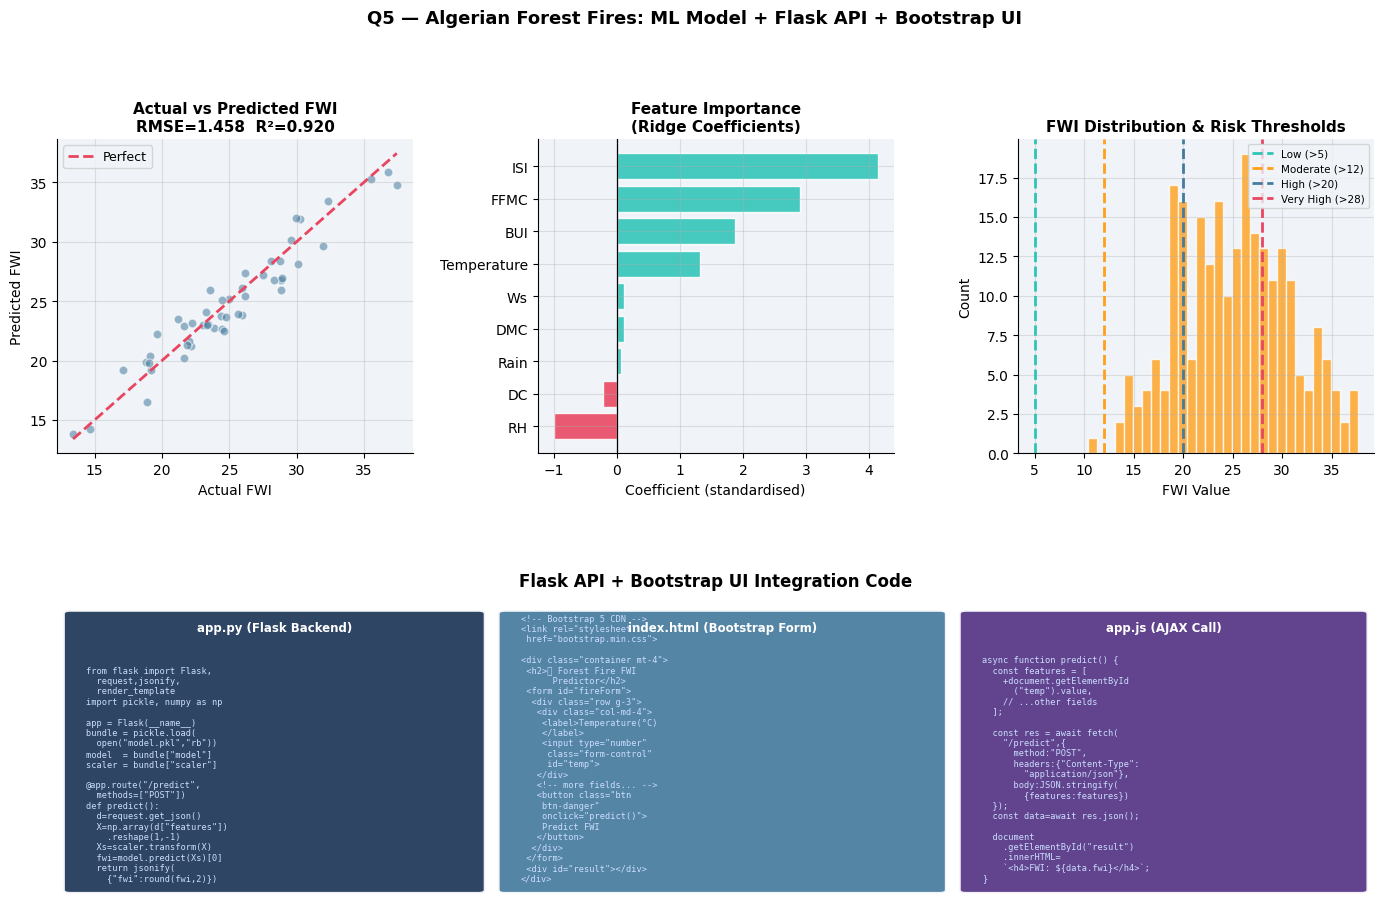

✅  Full integration pipeline demonstrated.


In [7]:
# ── Q5 (cont): Visualisation + Full app code snippets ────────────────────────

# Re-create model for plots
np.random.seed(42)
n = 244
df_fire = pd.DataFrame({
    'Temperature': np.random.uniform(22,42,n), 'RH': np.random.uniform(21,90,n),
    'Ws': np.random.uniform(6,29,n),           'Rain': np.random.uniform(0,1,n),
    'FFMC': np.random.uniform(28,93,n),        'DMC': np.random.uniform(1,65,n),
    'DC': np.random.uniform(7,220,n),          'ISI': np.random.uniform(0,18,n),
    'BUI': np.random.uniform(1,68,n),
})
df_fire['FWI'] = (0.25*df_fire['Temperature']+0.15*df_fire['FFMC']+
                   0.80*df_fire['ISI']+0.10*df_fire['BUI']-
                   0.05*df_fire['RH']+np.random.randn(n)*1.5).clip(0)
X = df_fire.drop('FWI',axis=1).values; y = df_fire['FWI'].values
X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.2,random_state=42)
sc = StandardScaler(); X_tr_s=sc.fit_transform(X_tr); X_te_s=sc.transform(X_te)
mdl = Ridge(alpha=1.0).fit(X_tr_s,y_tr); y_pred=mdl.predict(X_te_s)

fig = plt.figure(figsize=(17, 10))
gs5 = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Actual vs Predicted
ax1 = fig.add_subplot(gs5[0,0])
ax1.scatter(y_te, y_pred, alpha=0.55, color=C3, s=40, edgecolors='white')
mn,mx = y_te.min(),y_te.max()
ax1.plot([mn,mx],[mn,mx],'--',color=C1,lw=2,label='Perfect')
ax1.set_xlabel('Actual FWI'); ax1.set_ylabel('Predicted FWI')
r2=r2_score(y_te,y_pred); rmse=np.sqrt(mean_squared_error(y_te,y_pred))
ax1.set_title(f'Actual vs Predicted FWI\nRMSE={rmse:.3f}  R²={r2:.3f}',
               fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)

# Feature importance (Ridge coefficients)
ax2 = fig.add_subplot(gs5[0,1])
feat_names5 = list(df_fire.columns[:-1])
coefs5 = mdl.coef_
sorted5 = np.argsort(coefs5)
bar_c5 = [C1 if c<0 else C4 for c in coefs5[sorted5]]
ax2.barh(np.array(feat_names5)[sorted5], coefs5[sorted5],
          color=bar_c5, alpha=0.88, edgecolor='white')
ax2.axvline(0,color='black',lw=0.9)
ax2.set_title('Feature Importance\n(Ridge Coefficients)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Coefficient (standardised)')

# FWI distribution
ax3 = fig.add_subplot(gs5[0,2])
ax3.hist(df_fire['FWI'], bins=30, color=C5, alpha=0.80, edgecolor='white')
for thresh, label, col in [(5,'Low',C4),(12,'Moderate',C5),(20,'High',C3),(28,'Very High',C1)]:
    ax3.axvline(thresh, color=col, lw=2, ls='--', label=f'{label} (>{thresh})')
ax3.set_xlabel('FWI Value'); ax3.set_ylabel('Count')
ax3.set_title('FWI Distribution & Risk Thresholds', fontsize=11, fontweight='bold')
ax3.legend(fontsize=7.5)

# Full-width: Flask app + HTML skeleton
ax4 = fig.add_subplot(gs5[1,:])
ax4.axis('off')
ax4.set_xlim(0,10); ax4.set_ylim(0,5)
ax4.set_title('Flask API + Bootstrap UI Integration Code',
               fontsize=12, fontweight='bold')

blocks = [
    (0.1, 0.3, 3.1, 4.4, 'app.py (Flask Backend)',
     'from flask import Flask,\n  request,jsonify,\n  render_template\nimport pickle, numpy as np\n\napp = Flask(__name__)\nbundle = pickle.load(\n  open("model.pkl","rb"))\nmodel  = bundle["model"]\nscaler = bundle["scaler"]\n\n@app.route("/predict",\n  methods=["POST"])\ndef predict():\n  d=request.get_json()\n  X=np.array(d["features"])\n    .reshape(1,-1)\n  Xs=scaler.transform(X)\n  fwi=model.predict(Xs)[0]\n  return jsonify(\n    {"fwi":round(fwi,2)})',
     '#1D3557'),
    (3.4, 0.3, 3.3, 4.4, 'index.html (Bootstrap Form)',
     '<!-- Bootstrap 5 CDN -->\n<link rel="stylesheet"\n href="bootstrap.min.css">\n\n<div class="container mt-4">\n <h2>🌲 Forest Fire FWI\n      Predictor</h2>\n <form id="fireForm">\n  <div class="row g-3">\n   <div class="col-md-4">\n    <label>Temperature(°C)\n    </label>\n    <input type="number"\n     class="form-control"\n     id="temp">\n   </div>\n   <!-- more fields... -->\n   <button class="btn\n    btn-danger"\n    onclick="predict()">\n    Predict FWI\n   </button>\n  </div>\n </form>\n <div id="result"></div>\n</div>',
     '#457B9D'),
    (6.9, 0.3, 3.0, 4.4, 'app.js (AJAX Call)',
     'async function predict() {\n  const features = [\n    +document.getElementById\n      ("temp").value,\n    // ...other fields\n  ];\n\n  const res = await fetch(\n    "/predict",{\n      method:"POST",\n      headers:{"Content-Type":\n        "application/json"},\n      body:JSON.stringify(\n        {features:features})\n  });\n  const data=await res.json();\n\n  document\n    .getElementById("result")\n    .innerHTML=\n    `<h4>FWI: ${data.fwi}</h4>`;\n}',
     '#533483'),
]
for (bx,by,bw,bh,title,code_txt,col) in blocks:
    ax4.add_patch(mpatches.FancyBboxPatch(
        (bx,by), bw, bh, boxstyle='round,pad=0.05',
        facecolor=col, edgecolor='white', lw=2, alpha=0.92))
    ax4.text(bx+bw/2, by+bh-0.12, title, ha='center', va='top',
             fontsize=8.5, color='white', fontweight='bold')
    ax4.text(bx+0.12, by+0.12, code_txt, ha='left', va='bottom',
             fontsize=6.2, color='#ccddff', fontfamily='monospace')

plt.suptitle('Q5 — Algerian Forest Fires: ML Model + Flask API + Bootstrap UI',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('q5_forest_fire.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅  Full integration pipeline demonstrated.')


In [8]:
# ── Q5 (cont): Deployment files — Dockerfile, requirements.txt, Procfile ─────
print('='*65)
print('  DEPLOYMENT CONFIGURATION FILES')
print('='*65)

dockerfile = '''
# ── Dockerfile ─────────────────────────────────────────────────────
FROM python:3.10-slim

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 5000
CMD ["gunicorn", "--bind", "0.0.0.0:5000", "app:app"]
'''

requirements = '''
# ── requirements.txt ────────────────────────────────────────────────
flask==3.0.3
gunicorn==22.0.0
scikit-learn==1.5.0
numpy==1.26.4
pandas==2.2.2
'''

procfile = '''
# ── Procfile (Heroku) ────────────────────────────────────────────────
web: gunicorn app:app
'''

deploy_steps = '''
# ── Cloud Deployment Steps (AWS Elastic Beanstalk) ──────────────────
# 1. Install EB CLI
pip install awsebcli

# 2. Initialise EB app
eb init -p python-3.10 algerian-forest-fire-app

# 3. Create environment & deploy
eb create forest-fire-env
eb deploy

# 4. Open live URL
eb open

# ── OR: Heroku Deployment ────────────────────────────────────────────
git init
heroku create algerian-forest-fire
git push heroku main
heroku open
'''

for title, content in [
    ('Dockerfile', dockerfile),
    ('requirements.txt', requirements),
    ('Procfile', procfile),
    ('Deployment Commands', deploy_steps)
]:
    print(f'\n{"─"*65}')
    print(content)

print('='*65)
print('  LIBRARIES & APIs SUMMARY')
print('='*65)
libs = [
    ('scikit-learn',  'ML model (Ridge) + StandardScaler + metrics'),
    ('pickle',        'Serialise trained model to .pkl'),
    ('Flask',         'Python web framework — REST API /predict'),
    ('numpy/pandas',  'Data processing + feature array construction'),
    ('Bootstrap 5',   'Responsive HTML/CSS UI framework'),
    ('JS fetch()',    'Async HTTP POST from browser to Flask API'),
    ('gunicorn',      'Production WSGI server for Flask'),
    ('Docker',        'Containerise app for cloud deployment'),
    ('AWS EB / Heroku','Cloud platform for hosting the web app'),
]
for lib, desc in libs:
    print(f'  {lib:20} → {desc}')


  DEPLOYMENT CONFIGURATION FILES

─────────────────────────────────────────────────────────────────

# ── Dockerfile ─────────────────────────────────────────────────────
FROM python:3.10-slim

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 5000
CMD ["gunicorn", "--bind", "0.0.0.0:5000", "app:app"]


─────────────────────────────────────────────────────────────────

# ── requirements.txt ────────────────────────────────────────────────
flask==3.0.3
gunicorn==22.0.0
scikit-learn==1.5.0
numpy==1.26.4
pandas==2.2.2


─────────────────────────────────────────────────────────────────

# ── Procfile (Heroku) ────────────────────────────────────────────────
web: gunicorn app:app


─────────────────────────────────────────────────────────────────

# ── Cloud Deployment Steps (AWS Elastic Beanstalk) ──────────────────
# 1. Install EB CLI
pip install awsebcli

# 2. Initialise EB app
eb init -p python-3.10 algerian-forest-fire-app

# 3. C